# $Convolutional-Neural-Networks$

### $Image$

- We often have to deal with data that is complex


[[1 3 3 2 0 1 5 1 4 7 3 1 4 1 3 3]
 [2 5 4 1 8 7 6 8 8 8 3 5 1 3 0 1]
 [0 4 1 1 5 2 9 5 4 1 5 0 4 1 8 1]
 [9 5 1 1 7 4 3 2 7 3 6 7 7 2 8 8]
 [6 4 9 6 8 4 5 1 9 4 8 9 7 7 9 1]
 [9 3 2 7 6 0 5 6 6 3 2 5 0 9 5 2]
 [0 5 4 0 4 5 2 4 9 6 9 8 7 3 0 2]
 [7 5 2 0 7 7 4 0 7 1 3 5 3 0 0 9]
 [1 3 6 0 2 0 4 6 4 5 7 2 0 4 5 3]
 [6 2 9 0 0 8 9 9 6 8 2 0 9 3 2 4]
 [9 7 7 9 6 3 5 1 8 6 4 2 2 1 4 3]
 [2 1 3 8 7 1 0 7 7 4 5 3 5 4 4 4]
 [1 6 6 2 2 8 9 4 5 8 7 7 4 2 7 3]
 [0 7 1 8 8 3 2 6 4 7 1 7 8 4 8 2]
 [8 5 4 7 3 1 1 2 7 0 9 3 6 9 9 2]
 [6 4 1 6 5 3 2 5 4 8 2 5 2 7 2 5]]


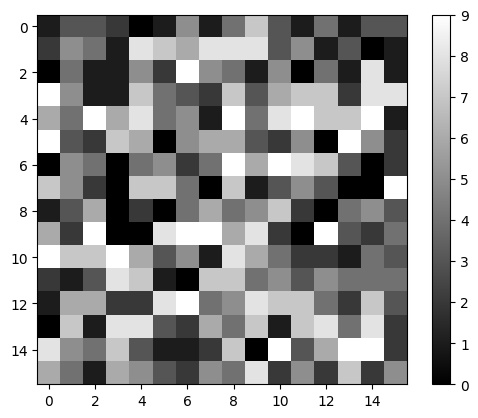

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# create an array 2D
image = np.random.randint(0,10, (16,16))

img = np.array([
    [1, 1, 1, 1],
    [1, 0, 1, 1],
    [1, 0, 0, 1],
    [1, 1, 1, 1],
])

print(image)

plt.imshow(image, cmap = 'gray')
plt.colorbar()
plt.show()

- We will use tensorflow to build a CNN model
    - Convolutional Neural Network

### **Convolutional Neural Network (CNN):**

- Use an operation called Convolution to process grid like data (images)
- They preserve spatial relationships 
- And learn from hierarchical features - Edge -> Shape -> Object
    
Use | Example
---|---
Image classification | ResNet, VGG for CIFAR-10, ImageNet
Object Detection | YOLO, SSD, Faster R-CNN
Image Segmentation | U-Net, Mask R-CNN

In [35]:
# implementation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dropout, Dense


- Input shape : 
    - (28,28,1) - Greyscale image
    - 3D images are color images

In [ ]:
# build our CNN

def my_cnn(input_shape = (28,28,1), num_classes = 10):
    model = Sequential()

    # part 1 === Edge and basic Shape Detection
    # 32 filters, 3x3 grid
    model.add(Conv2D(32, input_shape = input_shape, kernel_size=(3,3), activation= 'relu'))
    model.add(MaxPool2D(pool_size= (2,2)))

    # part 2 === Complex features detection
    model.add(Conv2D(64, kernel_size=(3,3), activation= 'relu'))
    model.add(MaxPool2D(pool_size= (2,2)))

    # convert to a 1D array
    model.add(Flatten()) 

    # 
    model.add(Dropout(0.5))

    # add a full connected thinking layer
    model.add(Dense(128, activation= 'relu'))

    # output layer
    model.add(Dense(units= num_classes, activation= 'softmax'))

    model.compile(
        optimizer = 'adam',
        loss = 'sparse_categorical_crossentropy',
        metrics = ['accuracy']

    )

    return model

Types of layers in a CNN:
- Conv2D:
    - It applies learnable filters (kernels) to an input image (or feature map) to extract spatial features such as edges, textures, and patterns
    ![](https://media.geeksforgeeks.org/wp-content/uploads/20230216175224/how-to-apply-a-2d-convolution-operation-in-pytorch.gif)
    - [Conv2D](https://www.geeksforgeeks.org/computer-vision/apply-a-2d-convolution-operation-in-pytorch/)

- MaxPool2D:
    - MaxPool2D is a pooling operation used in convolutional neural networks (CNNs) to downsample spatial dimensions (height and width) of feature maps while retaining the most important features. 
    ![](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*gaD6SJ6kQNVOclE_WkwLNQ.png)
    - 

### $Dataset$
- Load the dataset

In [ ]:
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [34]:
# X_train - 60,000 images of digits from 0 to 1 ---> shape = (60000, 28, 28)
# y_train - 
# X_test - 
# y_test - 

X_train[0]

np.set_printoptions(linewidth= 150)
print(X_train[0])
print("Label : ", y_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0   

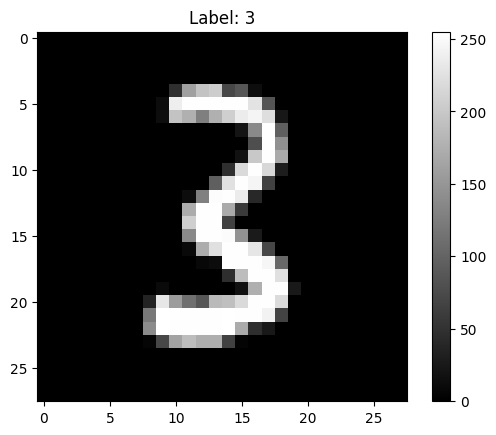

In [33]:
image_number = 50000

plt.imshow(X_train[image_number], cmap = 'gray')
plt.title(f"Label: {y_train[image_number]}")
plt.colorbar()
plt.show()

- Just 28 x 28 images, but 60K of them
A typical machine learning model will break at this scale of data
- This is where we need Deep Learning, Neural Networks

## $Training-the- Model$

- (60000, 28, 28) - 60K images each has 28 x 28 pixels
- CNN expects `4D tensor` (Batch_size, Height, Width, Channels)

In [ ]:
X_train.shape
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

In [42]:
model = my_cnn()

history = model.fit(X_train, y_train, batch_size = 64, epochs = 5, validation_split = 0.2, verbose = 0)

c:\Users\devid\Desktop\Nexperts Academy\AIML-nexperts3\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
# evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f'Accuracy = {test_accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9877 - loss: 0.0370
Accuracy = 98.77%


### Save the Model file

In [45]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

In [46]:
model.save('my_cnn.keras')

- Model parameters will define the complexity of the model
- Tensorflow, saved model formats:
    - .keras - recommended for Keras models
        - saves everything, packages the model architecture ---> weights and the optimizer states --> so you can train again from where you left off
    - .h5 - single file model format from older versions of TF and keras.
        - should not use this for new projects, it struggles to save custom code properly
    - SavedModel format - a folder and a file saved_model.pb file

# CNN using PyTorch